In [1]:
from deap import base, creator, tools, algorithms
import random

# --- Define problem (2 objectives: minimize LCOE, maximize CF) ---
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))  # both minimized
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Decision variables: [pv_mw, csp_mw, sm, tes_hours]
BOUNDS = [(0, 500), (0, 200), (1, 4), (0, 16)]

def random_ind():
    return [random.uniform(lo, hi) for lo, hi in BOUNDS]

toolbox.register("individual", tools.initIterate, creator.Individual, random_ind)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation ---
def simulate(ind):
    pv_mw, csp_mw, sm, tes = ind
    # replace below with your PySAM model
    annual_energy = pv_mw*2000 + csp_mw*4000*(0.2+0.05*tes)
    capex = pv_mw*650e3 + csp_mw*3.2e6 + tes*1e7
    opex = 0.025*capex
    lcoe = (capex*0.085 + opex) / annual_energy
    cf = annual_energy / (100*8760)  # vs 100 MW cap
    return lcoe, -cf  # both minimized

toolbox.register("evaluate", simulate)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=[b[0] for b in BOUNDS],
                 up=[b[1] for b in BOUNDS], eta=15.0)
toolbox.register("mutate", tools.mutPolynomialBounded,
                 low=[b[0] for b in BOUNDS], up=[b[1] for b in BOUNDS],
                 eta=20.0, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# --- Run ---
pop = toolbox.population(n=80)
algorithms.eaMuPlusLambda(pop, toolbox,
                          mu=80, lambda_=80,
                          cxpb=0.9, mutpb=0.1,   # <= sum is 1.0 now
                          ngen=60, verbose=True)


# --- Extract Pareto front ---
pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
for ind in pareto[:10]:
    print(ind, ind.fitness.values)


gen	nevals
0  	80    
1  	80    
2  	80    
3  	80    
4  	80    
5  	80    
6  	80    
7  	80    
8  	80    
9  	80    
10 	80    
11 	80    
12 	80    
13 	80    
14 	80    
15 	80    
16 	80    
17 	80    
18 	80    
19 	80    
20 	80    
21 	80    
22 	80    
23 	80    
24 	80    
25 	80    
26 	80    
27 	80    
28 	80    
29 	80    
30 	80    
31 	80    
32 	80    
33 	80    
34 	80    
35 	80    
36 	80    
37 	80    
38 	80    
39 	80    
40 	80    
41 	80    
42 	80    
43 	80    
44 	80    
45 	80    
46 	80    
47 	80    
48 	80    
49 	80    
50 	80    
51 	80    
52 	80    
53 	80    
54 	80    
55 	80    
56 	80    
57 	80    
58 	80    
59 	80    
60 	80    
[499.8459046709244, 0.3891193244973916, 1.2075472959633369, 0.12803812509103896] (36.016323418424875, -1.1415674306200865)
[499.8986503737419, 199.23240097800502, 3.5844782098280366, 15.946329821204698] (68.76982253185258, -2.0486168229943407)
[499.8569792055568, 131.3424094390248, 1.83474198439542, 15.99033637068530

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |     1000 |     12 |  0.000000E+00 |  2.017883E+02 |             - |             -
     2 |     2000 |     18 |  0.000000E+00 |  6.337495E+01 |  0.0508187149 |         ideal
     3 |     3000 |     24 |  0.000000E+00 |  8.1259624421 |  0.0143963694 |         ideal
     4 |     4000 |     40 |  0.000000E+00 |  0.000000E+00 |  0.0180323597 |         ideal
     5 |     5000 |     43 |  0.000000E+00 |  0.000000E+00 |  0.3213343936 |         nadir
     6 |     6000 |     47 |  0.000000E+00 |  0.000000E+00 |  0.0418655801 |         ideal
     7 |     7000 |     54 |  0.000000E+00 |  0.000000E+00 |  0.0493448844 |         nadir
     8 |     8000 |     69 |  0.000000E+00 |  0.000000E+00 |  0.0220708981 |         ideal
     9 |     9000 |     84 |  0.000000E+00 |  0.000000E+00 |  0.0300882492 |         nadir
    10 |    10000 |    102 |  0.000000E+00 |  0.000000E+00 |  0.0035057546 |             f

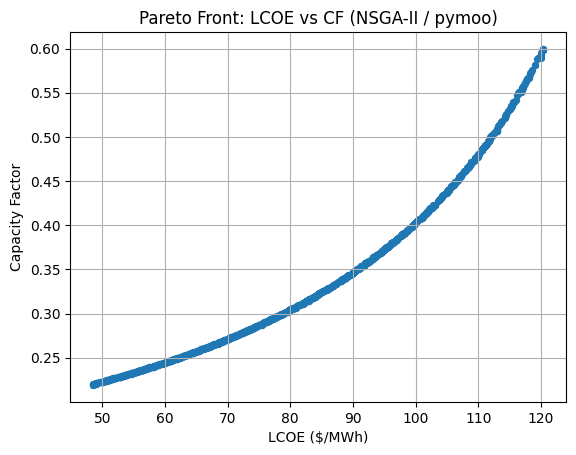

In [2]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.termination import get_termination
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

HOURS = 8760
CRF = 0.085                 # example capital recovery factor
EXPORT_CAP_MW = 100.0       # AC export cap (set None to disable)

# Bounds: pv_dc_mw, csp_turbine_mw, solar_multiple, tes_hours
XL = np.array([  0.0,   0.0, 1.0,  0.0])
XU = np.array([500.0, 200.0, 4.0, 16.0])

class HybridProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=4, n_obj=2,
                         n_constr=0 if EXPORT_CAP_MW is None else 1,
                         xl=XL, xu=XU)

    def _evaluate(self, x, out, *args, **kwargs):
        pv_dc_mw, csp_mw, sm, tes_h = x

        # --- Surrogate energy model (replace with your PySAM models) ---
        # PV
        pv_cf = 0.22
        pv_ac_mw = pv_dc_mw / 1.2 * 0.98
        pv_e_mwh = pv_ac_mw * pv_cf * HOURS

        # CSP tower + TES (very rough saturation-like growth)
        csp_cf_base = 0.20 + 0.12*(sm-1.0) + 0.015*tes_h
        csp_cf = np.clip(csp_cf_base, 0.05, 0.60)
        csp_e_mwh = csp_mw * csp_cf * HOURS

        annual_e = pv_e_mwh + csp_e_mwh

        # --- Surrogate cost model (replace with your Excel/Python model) ---
        pv_capex_per_kw = 650.0
        csp_turbine_per_kw = 3200.0
        csp_field_k_per_sm_per_mw = 700.0
        tes_per_kwh_th = 45.0
        eta_el = 0.40

        tes_kwh_e = csp_mw * tes_h * 1000.0
        tes_kwh_th = tes_kwh_e / eta_el

        capex_pv  = pv_dc_mw * 1000.0 * pv_capex_per_kw
        capex_csp = (csp_mw * 1000.0 * csp_turbine_per_kw
                     + csp_mw * 1000.0 * csp_field_k_per_sm_per_mw * max(0.0, sm-1.0))
        capex_tes = tes_kwh_th * tes_per_kwh_th
        capex     = capex_pv + capex_csp + capex_tes

        opex = 0.025 * capex + 3.0 * annual_e

        # Objectives
        if annual_e <= 1e-9:
            lcoe = 1e9
            cf = 0.0
        else:
            lcoe = (capex * CRF + opex) / annual_e
            denom = (EXPORT_CAP_MW if EXPORT_CAP_MW else (pv_ac_mw + csp_mw)) * HOURS
            cf = annual_e / max(1e-6, denom)

        F1 = lcoe           # minimize
        F2 = -cf            # maximize CF via minimizing -CF
        out["F"] = [F1, F2]

        # Optional hard constraint: nameplate must not exceed cap
        if EXPORT_CAP_MW is not None:
            nameplate_sum = pv_ac_mw + csp_mw
            # G <= 0 is feasible
            out["G"] = [nameplate_sum - EXPORT_CAP_MW]

# --- Build algorithm ---
algorithm = NSGA2(
    pop_size=1000,
    sampling=FloatRandomSampling(),
    crossover=SBX(eta=15, prob=0.9),
    mutation=PolynomialMutation(eta=20, prob=0.2),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 80)

# --- Optimize ---
problem = HybridProblem()
res = minimize(problem, algorithm, termination, seed=1, verbose=True)

# --- Gather results ---
F = res.F                    # shape (n_pareto, 2) -> [LCOE, -CF]
X = res.X                    # shape (n_pareto, 4) -> decision vectors
lcoe = F[:, 0]
cf = -F[:, 1]

# Print top 10 Pareto points
print("\nPareto (first 10):  LCOE  |   CF   | [pv_dc_mw, csp_mw, SM, TES_h]")
for i in np.argsort(lcoe)[:10]:
    print(f"{lcoe[i]:7.2f}  |  {cf[i]:.3f} | {X[i]}")

# --- Plot Pareto front ---
plt.figure()
plt.scatter(lcoe, cf, s=18)
plt.xlabel("LCOE ($/MWh)")
plt.ylabel("Capacity Factor")
plt.title("Pareto Front: LCOE vs CF (NSGA-II / pymoo)")
plt.grid(True)
plt.show()
